# Backfill missing raw `aggTrades` days

Этот ноутбук точечно дозагружает только три отсутствующие дневные партиции в `raw/aggTrades`:

- `2020-03-15`
- `2022-04-19`
- `2022-05-01`

Он использует настройки из локального `.env`, скачивает daily-архивы Binance Vision, приводит данные к схеме, которую ожидает `aggregate_features.py`, и загружает parquet в S3-compatible storage.

По умолчанию уже существующие партиции **не перезаписываются**.

In [1]:
from __future__ import annotations

import io
import zipfile
from datetime import date

import pandas as pd
import requests

from aggregate_features import make_s3_client, raw_agg_trades_key, s3_key_exists
from config_loader import load_settings

MISSING_DAYS = ["2020-03-15", "2022-04-19", "2022-05-01"]
FORCE_OVERWRITE = False
BINANCE_VISION_BASE_URL = "https://data.binance.vision/data/spot/daily/aggTrades"

settings = load_settings()
s3_client = make_s3_client(settings)

print(f"symbol={settings.symbol}")
print(f"bucket={settings.s3_bucket}")
print(f"raw_prefix={settings.raw_prefix}")
print(f"days={MISSING_DAYS}")
print(f"force_overwrite={FORCE_OVERWRITE}")

symbol=ADAUSDT
bucket=binance-data-downloader
raw_prefix=raw
days=['2020-03-15', '2022-04-19', '2022-05-01']
force_overwrite=False


## Вспомогательные функции

Binance daily `aggTrades` CSV обычно идёт без заголовка. Для совместимости с текущим проектом оставляем только нужные поля:

- `transact_time`
- `price`
- `quantity`
- `is_buyer_maker`

In [2]:
BINANCE_AGG_TRADES_COLUMNS = [
    "agg_trade_id",
    "price",
    "quantity",
    "first_trade_id",
    "last_trade_id",
    "transact_time",
    "is_buyer_maker",
    "is_best_match",
]


def archive_url(symbol: str, day: str) -> str:
    return f"{BINANCE_VISION_BASE_URL}/{symbol}/{symbol}-aggTrades-{day}.zip"


def download_daily_agg_trades(symbol: str, day: str) -> pd.DataFrame:
    url = archive_url(symbol, day)
    response = requests.get(url, timeout=120)
    response.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
        csv_names = [name for name in archive.namelist() if name.endswith(".csv")]
        if len(csv_names) != 1:
            raise ValueError(f"Expected exactly one CSV in {url}, got {csv_names}")
        with archive.open(csv_names[0]) as csv_file:
            df = pd.read_csv(csv_file, header=None, names=BINANCE_AGG_TRADES_COLUMNS)

    expected_columns = set(BINANCE_AGG_TRADES_COLUMNS)
    missing_columns = sorted(expected_columns - set(df.columns))
    if missing_columns:
        raise ValueError(f"Missing expected Binance columns for {day}: {missing_columns}")

    normalized = df[["transact_time", "price", "quantity", "is_buyer_maker"]].copy()
    normalized["transact_time"] = pd.to_numeric(normalized["transact_time"], errors="raise").astype("int64")
    normalized["price"] = pd.to_numeric(normalized["price"], errors="raise")
    normalized["quantity"] = pd.to_numeric(normalized["quantity"], errors="raise")
    normalized["is_buyer_maker"] = normalized["is_buyer_maker"].astype("bool")

    utc_dates = pd.to_datetime(normalized["transact_time"], unit="ms", utc=True).dt.date
    requested_day = date.fromisoformat(day)
    if not utc_dates.eq(requested_day).all():
        actual_dates = sorted({str(value) for value in utc_dates.unique()})
        raise ValueError(f"Unexpected UTC dates in archive for {day}: {actual_dates}")

    return normalized


def upload_daily_agg_trades(symbol: str, day: str) -> dict[str, object]:
    key = raw_agg_trades_key(symbol=symbol, day=day, settings=settings)
    already_exists = s3_key_exists(s3_client, settings.s3_bucket, key)

    if already_exists and not FORCE_OVERWRITE:
        return {
            "date": day,
            "rows": None,
            "key": key,
            "status": "skipped_exists",
        }

    df = download_daily_agg_trades(symbol=symbol, day=day)
    buffer = io.BytesIO()
    df.to_parquet(buffer, index=False, engine="pyarrow", compression="zstd")
    s3_client.put_object(Bucket=settings.s3_bucket, Key=key, Body=buffer.getvalue())

    return {
        "date": day,
        "rows": len(df),
        "key": key,
        "status": "uploaded",
    }

## Проверка плана перед записью

Эта ячейка ничего не меняет: она только показывает, какие ключи будут затронуты и существуют ли они уже.

In [3]:
plan = []
for day in MISSING_DAYS:
    key = raw_agg_trades_key(symbol=settings.symbol, day=day, settings=settings)
    plan.append(
        {
            "date": day,
            "key": key,
            "already_exists": s3_key_exists(s3_client, settings.s3_bucket, key),
        }
    )

pd.DataFrame(plan)

,date,key,already_exists
0,2020-03-15,raw/aggTrades/symbol=ADAUSDT/date=2020-03-15/d...,False
1,2022-04-19,raw/aggTrades/symbol=ADAUSDT/date=2022-04-19/d...,False
2,2022-05-01,raw/aggTrades/symbol=ADAUSDT/date=2022-05-01/d...,False


## Точечная догрузка

In [4]:
results = [upload_daily_agg_trades(symbol=settings.symbol, day=day) for day in MISSING_DAYS]
results_df = pd.DataFrame(results)
results_df

,date,rows,key,status
0,2020-03-15,40610,raw/aggTrades/symbol=ADAUSDT/date=2020-03-15/d...,uploaded
1,2022-04-19,53971,raw/aggTrades/symbol=ADAUSDT/date=2022-04-19/d...,uploaded
2,2022-05-01,109916,raw/aggTrades/symbol=ADAUSDT/date=2022-05-01/d...,uploaded


## Пост-проверка

Проверяем, что ровно нужные три ключа теперь существуют в storage.

In [5]:
verification = []
for day in MISSING_DAYS:
    key = raw_agg_trades_key(symbol=settings.symbol, day=day, settings=settings)
    verification.append(
        {
            "date": day,
            "key": key,
            "exists_after_run": s3_key_exists(s3_client, settings.s3_bucket, key),
        }
    )

pd.DataFrame(verification)

,date,key,exists_after_run
0,2020-03-15,raw/aggTrades/symbol=ADAUSDT/date=2020-03-15/d...,True
1,2022-04-19,raw/aggTrades/symbol=ADAUSDT/date=2022-04-19/d...,True
2,2022-05-01,raw/aggTrades/symbol=ADAUSDT/date=2022-05-01/d...,True


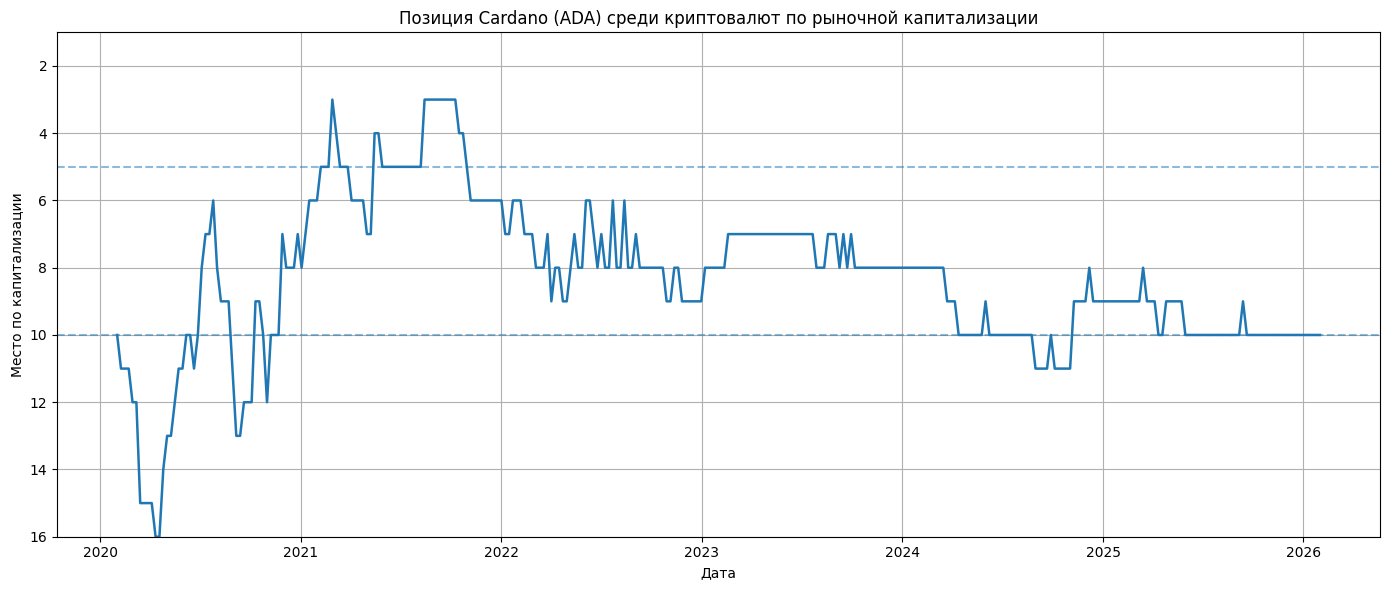

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv("ada_only.csv")

# =========================================================
# FILTER REAL ADA
# =========================================================

df = df[
    (df["symbol"] == "ADA") &
    (df["name"] == "Cardano")
].copy()

# =========================================================
# PREPARE DATA
# =========================================================

df["snapshot_date"] = pd.to_datetime(
    df["snapshot_date"],
    format="%Y%m%d"
)

df = df.sort_values("snapshot_date")

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(14, 6))

plt.plot(
    df["snapshot_date"],
    df["rank"],
    linewidth=1.8
)

# top levels
plt.axhline(5, linestyle="--", alpha=0.5)
plt.axhline(10, linestyle="--", alpha=0.5)

# invert axis
plt.gca().invert_yaxis()

# compact axis
plt.ylim(16, 1)

plt.title(
    "Позиция Cardano (ADA) среди криптовалют по рыночной капитализации"
)

plt.xlabel("Дата")
plt.ylabel("Место по капитализации")

plt.grid(True)

plt.tight_layout()

plt.show()